In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"]

e = 7
session_name = session_names[e]

In [ ]:
"""Load the dataset"""
save_path = "Z:\Jasmine_Laurence\summary_plots\Replay\SSdecoder"
# save time, position, bin_width and spikes
data = np.load(save_path + '\\' + session_name + 'state_space_decoder_data.npz')
time = data['time']
position = data['position']
bin_width = data['bin_width']
spikes = data['spikes'].T
sampling_frequency = 1000

In [10]:
import warnings
np.warnings = warnings
from replay_trajectory_classification import SortedSpikesDecoder, Environment, RandomWalk, estimate_movement_var

movement_var = estimate_movement_var(position, sampling_frequency)

environment = Environment(place_bin_size=np.sqrt(movement_var))
transition_type = RandomWalk(movement_var=movement_var)

decoder = SortedSpikesDecoder(
    environment=environment,
    transition_type=transition_type,
    sorted_spikes_algorithm='spiking_likelihood_kde',
    sorted_spikes_algorithm_params={'block_size': None,
                                    'position_std': [3.0],
                                    'use_diffusion': False},
)
decoder.fit(position, spikes)

SortedSpikesDecoder(environment=Environment(environment_name='',
                                            place_bin_size=12.416977516767874,
                                            track_graph=None,
                                            edge_order=None,
                                            edge_spacing=None,
                                            is_track_interior=None,
                                            position_range=None,
                                            infer_track_interior=True,
                                            fill_holes=False,
                                            dilate=False,
                                            bin_count_threshold=0),
                    infer_track_interior=True,
                    initial_conditions_type=UniformInitialConditions(),
                    sorted_spikes_algorithm='spiking_likelihood_kde',
                    sorted_spikes_algorithm_params={'block_size': None,
                                                    'position_std': [3.0],
                                                    'use_diffusion': False},
                    transition_type=RandomWalk(environment_name='',
                                               movement_var=154.1813306519189,
                                               movement_mean=0.0,
                                               use_diffusion=False))

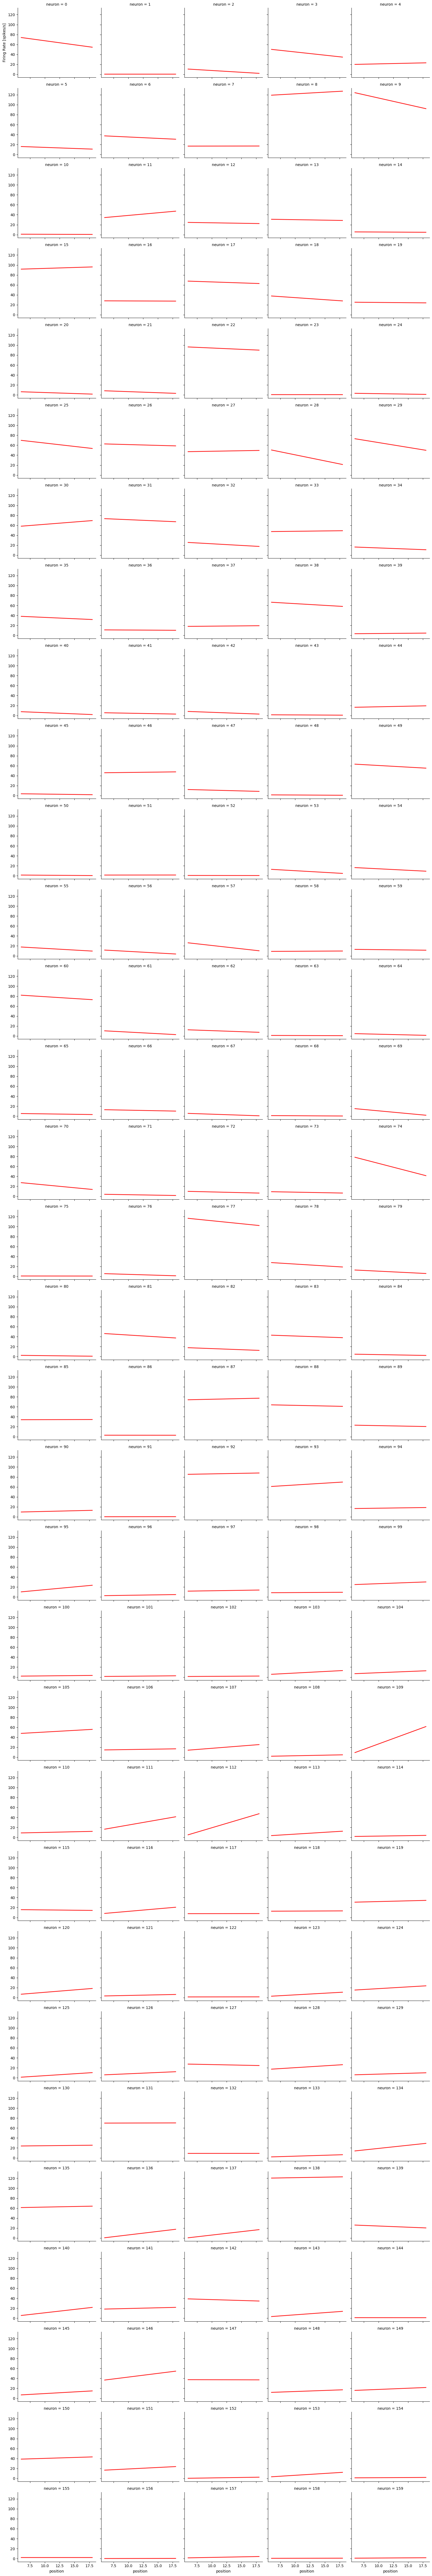

In [11]:
"""Look at the escape tuning"""
g = (decoder.place_fields_ * sampling_frequency).plot(
        x="position", col="neuron", col_wrap=5, color="red", linewidth=2, alpha=0.9, zorder=1, label="Predicted")
g.axes[0, 0].set_ylabel("Firing Rate [spikes/s]")
# for ax, place_field in zip(g.axes.flat, place_fields.T):
#     ax.plot(position, place_field, linewidth=2, color="black", zorder=-1, label="True")
sns.despine()

In [24]:
results.acausal_posterior

<xarray.DataArray 'acausal_posterior' (time: 179012, position: 2)> Size: 3MB
array([[0.53252958, 0.46747042],
       [0.54276537, 0.45723463],
       [0.61605075, 0.38394925],
       ...,
       [0.70590434, 0.29409566],
       [0.66560065, 0.33439935],
       [0.52660892, 0.47339108]])
Coordinates:
  * time      (time) float64 1MB 0.0 0.001 0.002 0.003 ... 179.0 179.0 179.0
  * position  (position) float64 16B 6.0 18.0

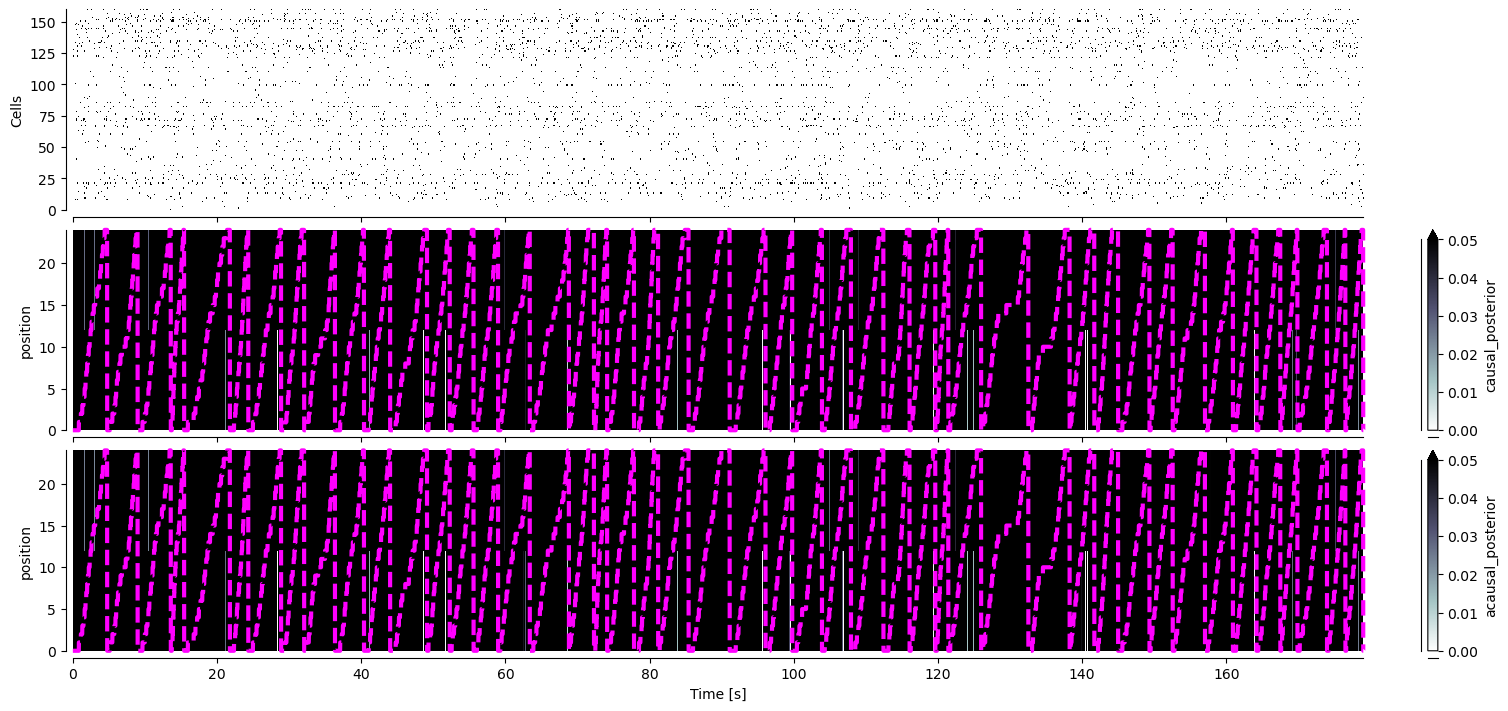

In [23]:
"""Estimate the escape position from the model"""
# results = decoder.predict(spikes, time=time)

fig, axes = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

axes[0].imshow(spikes.T, cmap="gray_r", aspect="auto", interpolation="none",
                    extent=(0, spikes.shape[0]/(1/bin_width), 0, spikes.shape[1]))
axes[0].set_ylabel('Cells')

results.causal_posterior.plot(x="time", y="position", ax=axes[1], cmap="bone_r", vmin=0.0, vmax=0.05, clip_on=False)
axes[1].plot(time, position, color="magenta", linestyle="--", linewidth=3, clip_on=False)
axes[1].set_xlabel("")
results.acausal_posterior.plot(x="time", y="position", ax=axes[2], cmap="bone_r", vmin=0.0, vmax=0.05, clip_on=False)
axes[2].plot(time, position, color="magenta", linestyle="--", linewidth=3, clip_on=False)
axes[2].set_xlabel('Time [s]')

# for ax in axes:
#     ax.set_xlim(0,10)

sns.despine(offset=5)